In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def find_repo_root(marker: str = "requirements.txt") -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not locate repo root (no {marker} found above {Path.cwd()})")

RESULTS_DIR = find_repo_root() / "data" / "results"

# Map result filename -> display label. Add an entry here once a new model's
# test run has been saved (e.g. "test_har_log_cj.parquet": "CJ").
RESULT_FILES = {
    "test_har_log_rv.parquet": "RV",
    "test_har_log_bv.parquet": "BV",
    "test_har_cj.parquet": "CJ",
}

def load_result(filename: str) -> pd.DataFrame:
    df = pd.read_parquet(RESULTS_DIR / filename)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    predicted_col = next(c for c in df.columns if c.startswith("predicted_"))
    actual_col = next(c for c in df.columns if c.startswith("actual_"))
    df = df.rename(columns={predicted_col: "predicted", actual_col: "actual"})
    # CJ's predicted/actual are saved on the raw RV (variance) scale, while the
    # RV/BV results above are log-scale. Log-transform here so all models land on
    # the same axis/units for the overlay plot and MSE comparison below.
    if not filename.startswith("test_har_log"):
        df["predicted"] = np.log(df["predicted"])
        df["actual"] = np.log(df["actual"])
        df["MSE"] = (df["predicted"] - df["actual"]) ** 2
    return df.set_index("timestamp").sort_index()

results = {label: load_result(filename) for filename, label in RESULT_FILES.items()}
results.keys()

dict_keys(['RV', 'BV', 'CJ'])

## Per-model: predicted vs. actual

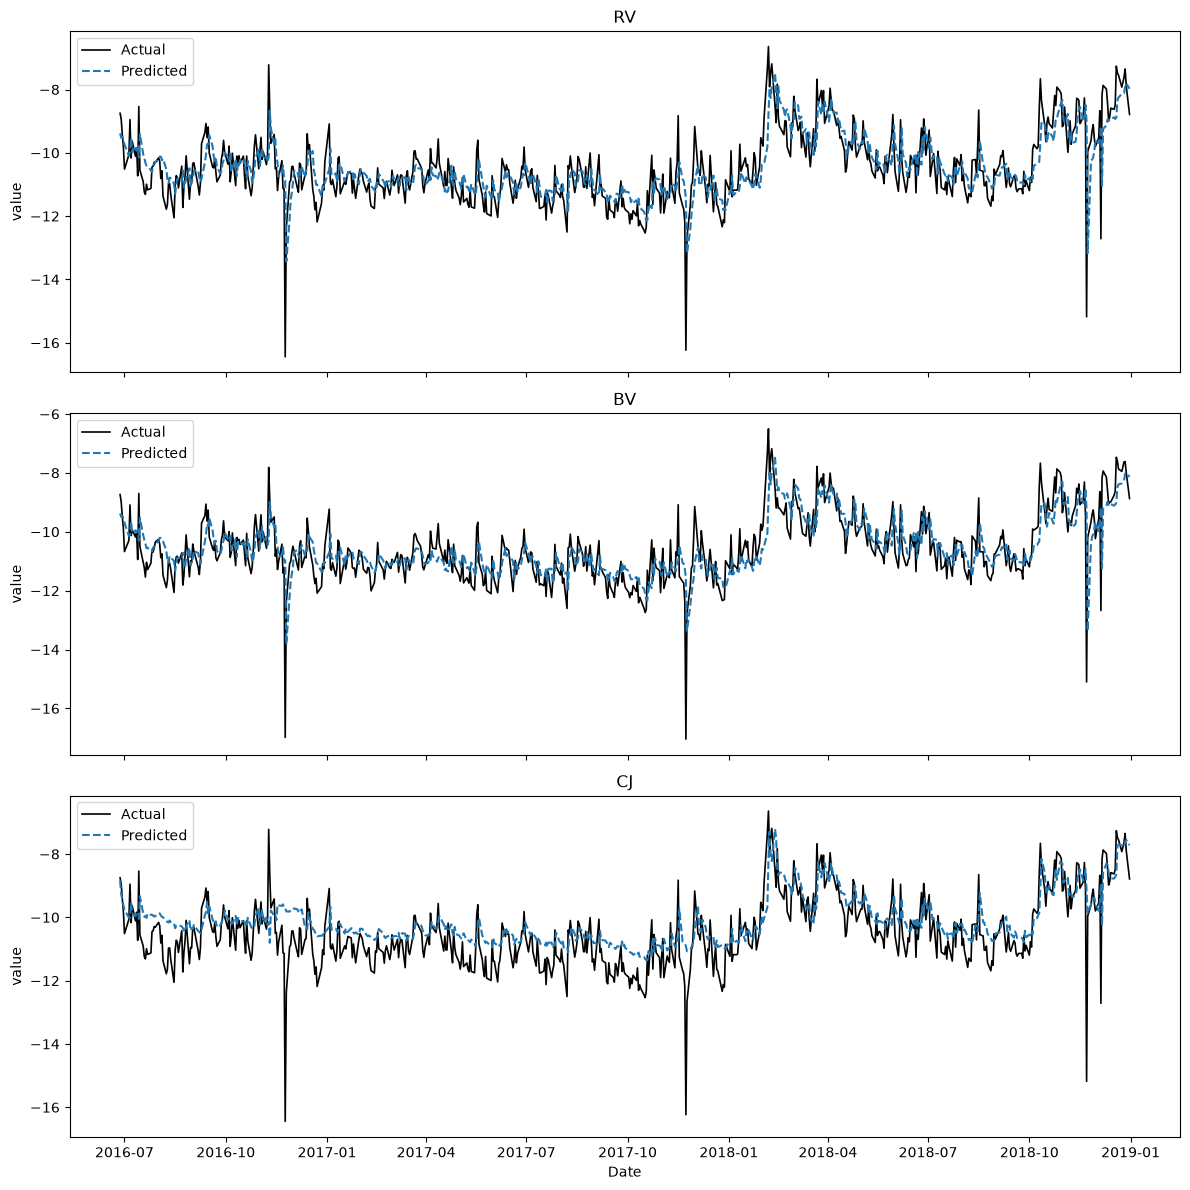

In [2]:
fig, axes = plt.subplots(len(results), 1, figsize=(12, 4 * len(results)), sharex=True)
if len(results) == 1:
    axes = [axes]

for ax, (label, df) in zip(axes, results.items()):
    ax.plot(df.index, df["actual"], label="Actual", color="black", linewidth=1.2)
    ax.plot(df.index, df["predicted"], label="Predicted", color="tab:blue", linestyle="--")
    ax.set_title(label)
    ax.set_ylabel("value")
    ax.legend()

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## All models overlaid

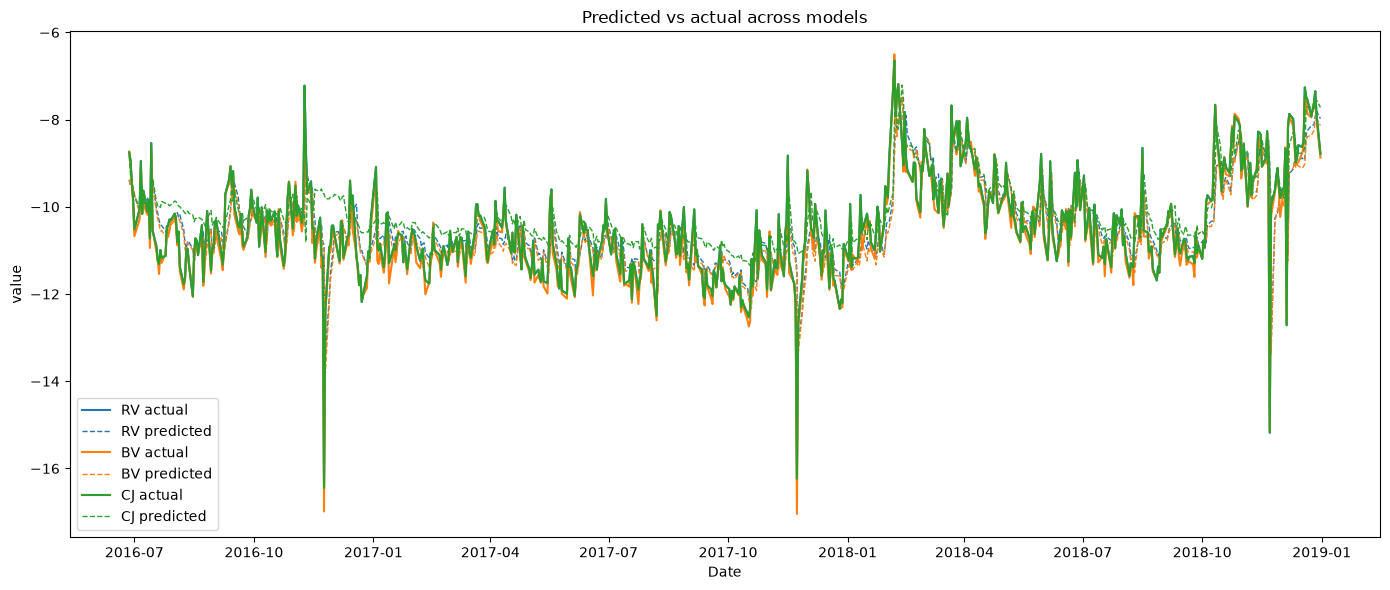

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for (label, df), color in zip(results.items(), colors):
    ax.plot(df.index, df["actual"], label=f"{label} actual", color=color, linewidth=1.5)
    ax.plot(df.index, df["predicted"], label=f"{label} predicted", color=color, linestyle="--", linewidth=1)

ax.set_xlabel("Date")
ax.set_ylabel("value")
ax.set_title("Predicted vs actual across models")
ax.legend()
plt.tight_layout()
plt.show()

## Error metrics across models

Only includes a metric column if every loaded result has it (e.g. QLIKE is currently only
saved for some rvMetric runs), so this won't break as new models are added.

In [4]:
metric_cols = [c for c in ("MSE", "QLIKE") if all(c in df.columns for df in results.values())]

summary = pd.DataFrame({
    label: {**{f"mean_{m}": df[m].mean() for m in metric_cols}, "rmse": df["MSE"].mean() ** 0.5}
    for label, df in results.items()
}).T
summary

,mean_MSE,rmse
RV,0.594459,0.771012
BV,0.610343,0.781245
CJ,0.708927,0.841978


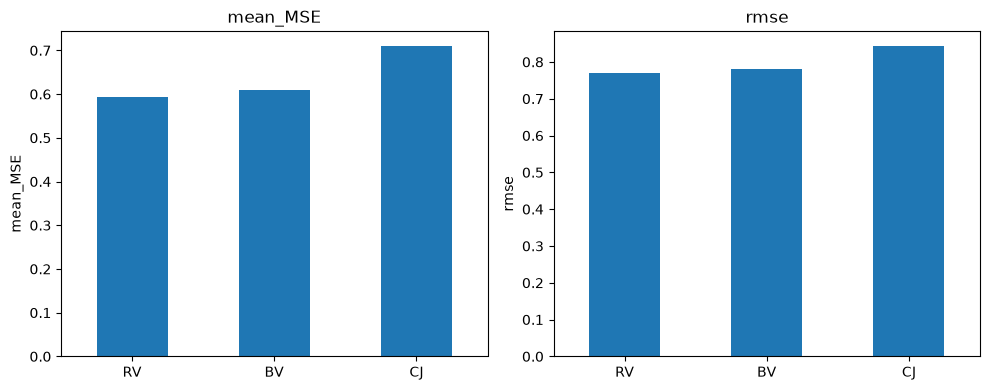

In [5]:
fig, axes = plt.subplots(1, len(summary.columns), figsize=(5 * len(summary.columns), 4))
if len(summary.columns) == 1:
    axes = [axes]

for ax, col in zip(axes, summary.columns):
    summary[col].plot(kind="bar", ax=ax, color="tab:blue")
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()